In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io
from tensorflow import keras
from keras import layers
from keras.utils import load_img,np_utils, img_to_array, to_categorical
from sklearn.model_selection import train_test_split
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
image_folder = 'flowers/'
label_file = 'imagelabels.mat'

In [3]:
labels = scipy.io.loadmat(label_file)
data = labels['labels']

In [4]:
num_classes = np.max(data) + 1
data = to_categorical(data, num_classes=num_classes)


In [5]:
data = data.reshape(data.shape[1:])
data.shape

(8189, 103)

In [6]:
image_files = os.listdir(image_folder)
print(len(image_files))
files = [item for item in image_files if ')' not in item]
print(len(files))
files1 = [item for item in files if 'ipynb_checkpoints' not in item]
print(len(files1))

8189
8189
8189


In [7]:
image_files = os.listdir(image_folder)
print(len(files1))
images = []
for filename in files1:
  img = load_img(image_folder+"/"+filename, target_size=(128, 128))  # VGG16 expects input of size 224x224
  img_array = img_to_array(img)
  images1 = np.expand_dims(img_array, axis=0)
  images.append(images1)
images = np.array(images)
print(images.shape)

8189
(8189, 1, 128, 128, 3)


In [8]:
images /= 255.
images = images.reshape(8189, 128, 128, 3)
images.shape

(8189, 128, 128, 3)

In [9]:
train_images, test_images, train_labels, test_labels = train_test_split(images, data,train_size=0.8 ,test_size=0.2, random_state=42)

In [10]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(6551, 128, 128, 3)
(6551, 103)
(1638, 128, 128, 3)
(1638, 103)


In [11]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [12]:
model = Model(inputs=base_model.input, outputs=predictions)

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
model.fit(train_images, train_labels, epochs=80, validation_data=(test_images, test_labels))

Epoch 1/80
205/205 [==============================] - 1066s 5s/step - loss: 4.4661 - accuracy: 0.0504 - val_loss: 4.1085 - val_accuracy: 0.1838
Epoch 2/80
205/205 [==============================] - 484s 2s/step - loss: 3.9311 - accuracy: 0.1539 - val_loss: 3.5829 - val_accuracy: 0.2869
Epoch 3/80
205/205 [==============================] - 514s 3s/step - loss: 3.4624 - accuracy: 0.2358 - val_loss: 3.1727 - val_accuracy: 0.3498
Epoch 4/80
205/205 [==============================] - 518s 3s/step - loss: 3.0964 - accuracy: 0.3090 - val_loss: 2.8500 - val_accuracy: 0.4243
Epoch 5/80
205/205 [==============================] - 737s 4s/step - loss: 2.8372 - accuracy: 0.3543 - val_loss: 2.6185 - val_accuracy: 0.4487
Epoch 6/80
205/205 [==============================] - 840s 4s/step - loss: 2.5667 - accuracy: 0.4050 - val_loss: 2.3974 - val_accuracy: 0.5177
Epoch 7/80
205/205 [==============================] - 506s 2s/step - loss: 2.3751 - accuracy: 0.4463 - val_loss: 2.2246 - val_accuracy: 0.544

Epoch 58/80
205/205 [==============================] - 305s 1s/step - loss: 0.2656 - accuracy: 0.9467 - val_loss: 0.9042 - val_accuracy: 0.7631
Epoch 59/80
205/205 [==============================] - 305s 1s/step - loss: 0.2571 - accuracy: 0.9473 - val_loss: 0.8940 - val_accuracy: 0.7650
Epoch 60/80
205/205 [==============================] - 306s 1s/step - loss: 0.2587 - accuracy: 0.9487 - val_loss: 0.8945 - val_accuracy: 0.7643
Epoch 61/80
205/205 [==============================] - 307s 1s/step - loss: 0.2329 - accuracy: 0.9565 - val_loss: 0.8861 - val_accuracy: 0.7668
Epoch 62/80
205/205 [==============================] - 301s 1s/step - loss: 0.2393 - accuracy: 0.9530 - val_loss: 0.8856 - val_accuracy: 0.7637
Epoch 63/80
205/205 [==============================] - 300s 1s/step - loss: 0.2320 - accuracy: 0.9550 - val_loss: 0.8848 - val_accuracy: 0.7595
Epoch 64/80
205/205 [==============================] - 307s 1s/step - loss: 0.2256 - accuracy: 0.9560 - val_loss: 0.8709 - val_accuracy:

In [15]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {accuracy * 100}%")

52/52 [==============================] - 234s 5s/step - loss: 0.8577 - accuracy: 0.7723
Test Accuracy: 77.22832560539246%


In [16]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

In [35]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [44]:
pred=model.predict(test_images)
print("Predicted Probabilities -\n",pred[:4])
pred_digits=np.argmax(pred,axis=1)
print("\nPredicted Class [Highest Prob] -",pred_digits[:4])

52/52 [==============================] - 127s 2s/step
Predicted Probabilities -
 [[6.16408080e-09 3.46623687e-03 2.21897744e-06 9.54017509e-03
  9.80455242e-03 2.83584268e-06 7.07770050e-06 2.30652560e-03
  5.52658603e-05 2.38710945e-05 6.58764847e-08 7.53303431e-03
  5.48197931e-08 1.08128131e-06 9.97549523e-06 9.13699569e-06
  8.11535847e-06 4.67735163e-06 2.26759264e-04 5.54303115e-04
  7.99775240e-04 3.87880874e-07 6.50011771e-06 4.90637285e-06
  5.80635169e-05 9.66901462e-06 5.83267771e-04 3.64135485e-05
  3.67852372e-05 6.99142129e-06 2.01482966e-04 2.21076509e-04
  1.09674456e-02 3.50452609e-07 1.67763943e-03 9.95832750e-08
  2.28294884e-04 7.68910377e-06 2.00462546e-06 2.23051946e-04
  2.94432929e-03 3.83099768e-06 9.89363325e-05 4.80219513e-01
  1.14191859e-03 2.98522487e-02 5.43305869e-05 2.67450287e-06
  3.55452066e-05 6.84535223e-07 2.58143973e-09 5.38708363e-03
  2.09584377e-05 1.24742172e-03 3.91339154e-06 5.12043363e-04
  6.25638586e-06 7.31634645e-06 1.31531197e-05 4.49

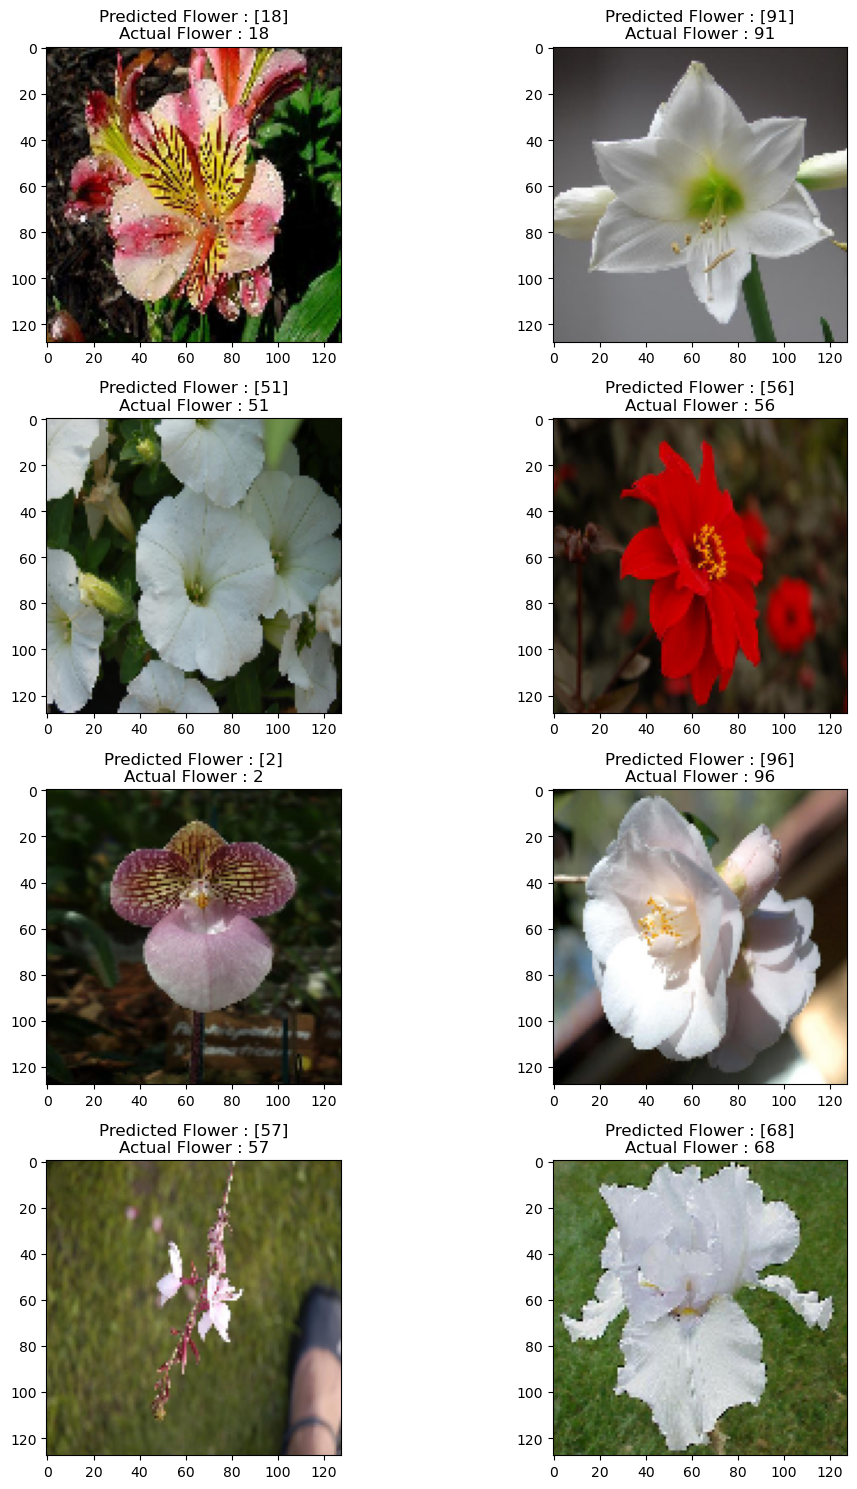

In [47]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(test_labels)):
    if(np.argmax(test_labels[i])==pred_digits[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(test_labels)):
    if(not np.argmax(test_labels[i])==pred_digits[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break  

import warnings
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig,ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        ax[i,j].imshow(test_images[prop_class[count]])
        ax[i,j].set_title("Predicted Flower : "+str([pred_digits[prop_class[count]]])+"\n"+"Actual Flower : "+str(np.argmax([test_labels[prop_class[count]]])))
        plt.tight_layout()
        count+=1